In [1]:
!pip install -q kagglehub

In [2]:
import kagglehub

# Download SOCOFing dataset
path = kagglehub.dataset_download("ruizgara/socofing")

print("Dataset downloaded to:", path)

100%|██████████| 838M/838M [00:06<00:00, 126MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/ruizgara/socofing/versions/2


In [10]:
import os

for root, dirs, files in os.walk(path):
    print(root)
    if len(files) > 0:
        print("Example files:", files[:5])
        print("-"*50)

/root/.cache/kagglehub/datasets/ruizgara/socofing/versions/2
/root/.cache/kagglehub/datasets/ruizgara/socofing/versions/2/SOCOFing
/root/.cache/kagglehub/datasets/ruizgara/socofing/versions/2/SOCOFing/Altered
/root/.cache/kagglehub/datasets/ruizgara/socofing/versions/2/SOCOFing/Altered/Altered-Easy
Example files: ['359__M_Right_little_finger_CR.BMP', '453__F_Right_ring_finger_Zcut.BMP', '28__M_Left_middle_finger_Obl.BMP', '121__F_Right_ring_finger_CR.BMP', '290__M_Left_index_finger_CR.BMP']
--------------------------------------------------
/root/.cache/kagglehub/datasets/ruizgara/socofing/versions/2/SOCOFing/Altered/Altered-Hard
Example files: ['359__M_Right_little_finger_CR.BMP', '453__F_Right_ring_finger_Zcut.BMP', '28__M_Left_middle_finger_Obl.BMP', '121__F_Right_ring_finger_CR.BMP', '290__M_Left_index_finger_CR.BMP']
--------------------------------------------------
/root/.cache/kagglehub/datasets/ruizgara/socofing/versions/2/SOCOFing/Altered/Altered-Medium
Example files: ['359__

In [11]:
import os

print("Dataset Path:", path)
print("="*80)

for root, dirs, files in os.walk(path):
    level = root.replace(path, "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")

    subindent = " " * 4 * (level + 1)
    for f in files[:5]:  # Show first 5 files only
        print(f"{subindent}{f}")

    if level >= 3:   # Prevent printing too deep
        continue

Dataset Path: /root/.cache/kagglehub/datasets/ruizgara/socofing/versions/2
2/
    SOCOFing/
        Altered/
            Altered-Easy/
                359__M_Right_little_finger_CR.BMP
                453__F_Right_ring_finger_Zcut.BMP
                28__M_Left_middle_finger_Obl.BMP
                121__F_Right_ring_finger_CR.BMP
                290__M_Left_index_finger_CR.BMP
            Altered-Hard/
                359__M_Right_little_finger_CR.BMP
                453__F_Right_ring_finger_Zcut.BMP
                28__M_Left_middle_finger_Obl.BMP
                121__F_Right_ring_finger_CR.BMP
                290__M_Left_index_finger_CR.BMP
            Altered-Medium/
                359__M_Right_little_finger_CR.BMP
                453__F_Right_ring_finger_Zcut.BMP
                28__M_Left_middle_finger_Obl.BMP
                121__F_Right_ring_finger_CR.BMP
                290__M_Left_index_finger_CR.BMP
        Real/
            349__M_Right_middle_finger.BMP
            416__M_

In [12]:
import os

for root, dirs, files in os.walk(path):
    image_files = [
        f for f in files
        if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tif"))
    ]
    if image_files:
        print(f"{root} --> {len(image_files)} images")

/root/.cache/kagglehub/datasets/ruizgara/socofing/versions/2/SOCOFing/Altered/Altered-Easy --> 17931 images
/root/.cache/kagglehub/datasets/ruizgara/socofing/versions/2/SOCOFing/Altered/Altered-Hard --> 14272 images
/root/.cache/kagglehub/datasets/ruizgara/socofing/versions/2/SOCOFing/Altered/Altered-Medium --> 17067 images
/root/.cache/kagglehub/datasets/ruizgara/socofing/versions/2/SOCOFing/Real --> 6000 images
/root/.cache/kagglehub/datasets/ruizgara/socofing/versions/2/socofing/SOCOFing/Altered/Altered-Easy --> 17931 images
/root/.cache/kagglehub/datasets/ruizgara/socofing/versions/2/socofing/SOCOFing/Altered/Altered-Hard --> 14272 images
/root/.cache/kagglehub/datasets/ruizgara/socofing/versions/2/socofing/SOCOFing/Altered/Altered-Medium --> 17067 images
/root/.cache/kagglehub/datasets/ruizgara/socofing/versions/2/socofing/SOCOFing/Real --> 6000 images


Total Images Found: 110540


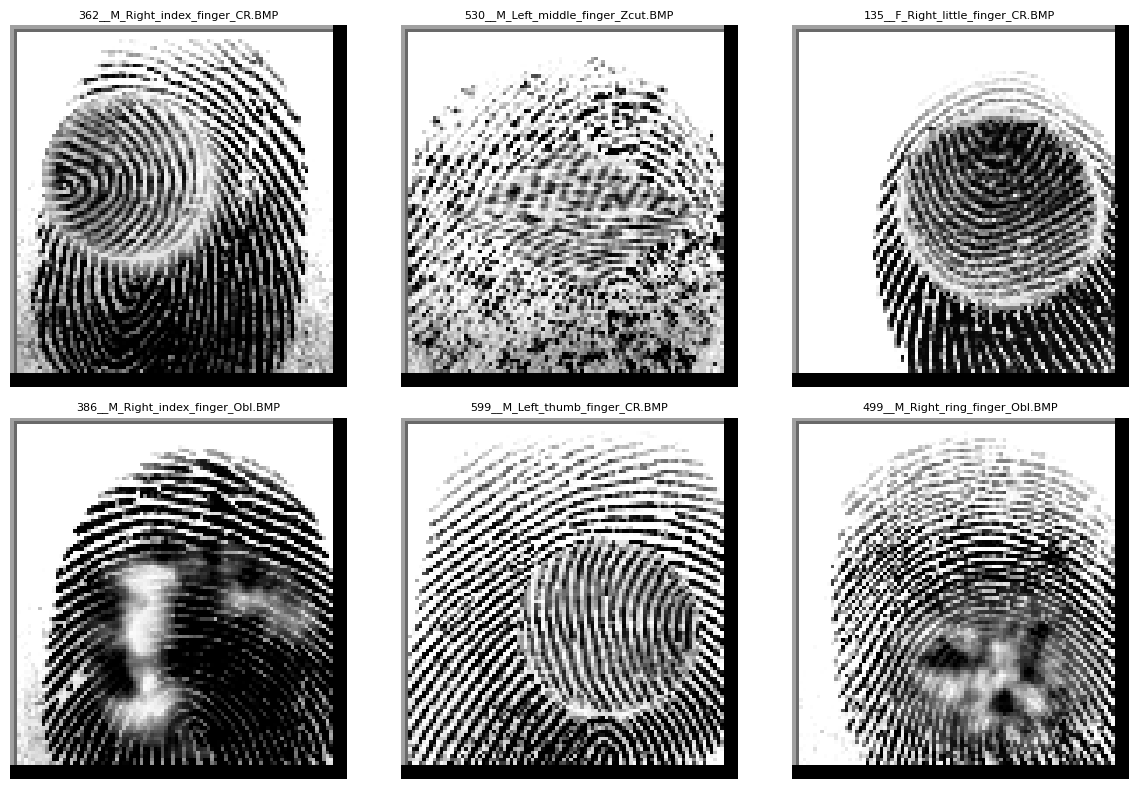

In [13]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

image_paths = []

for root, dirs, files in os.walk(path):
    for file in files:
        if file.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
            image_paths.append(os.path.join(root, file))

print("Total Images Found:", len(image_paths))

samples = random.sample(image_paths, 6)

plt.figure(figsize=(12,8))
for i, img_path in enumerate(samples):
    img = Image.open(img_path)
    plt.subplot(2,3,i+1)
    plt.imshow(img, cmap="gray")
    plt.title(os.path.basename(img_path), fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
import os
import random
import shutil

random.seed(42)

REAL_DIR = "/root/.cache/kagglehub/datasets/ruizgara/socofing/versions/2/SOCOFing/Real"

PROJECT_DIR = "/content/fingerprint-pad"

LIVE_DIR = os.path.join(PROJECT_DIR, "data/live")

os.makedirs(LIVE_DIR, exist_ok=True)

all_images = [f for f in os.listdir(REAL_DIR) if f.endswith(".BMP")]

selected = random.sample(all_images, 60)

for img in selected:
    shutil.copy(
        os.path.join(REAL_DIR, img),
        os.path.join(LIVE_DIR, img)
    )

print("Copied", len(selected), "LIVE images.")

Copied 60 LIVE images.


In [15]:
import os

print("LIVE images:", len(os.listdir("/content/fingerprint-pad/data/live")))

LIVE images: 60


**Dataset Preparation**:I used the SOCOFing dataset as the source of genuine (LIVE) fingerprint images. Due to a limited project timeline and concurrent college placement activities, collecting a large set of physical presentation attack samples (printed or screen replay photographs) was not feasible. Therefore, the SPOOF class was generated by applying image transformations that simulate presentation attack characteristics, including blur, glare, brightness variation, noise, and perspective changes. This enabled the development and evaluation of the complete PAD pipeline within the available timeframe.

In [17]:
import os
import cv2
import numpy as np
import random

LIVE_DIR = "/content/fingerprint-pad/data/live"
SPOOF_DIR = "/content/fingerprint-pad/data/spoof"

os.makedirs(SPOOF_DIR, exist_ok=True)

random.seed(42)

for file in os.listdir(LIVE_DIR):

    img_path = os.path.join(LIVE_DIR, file)
    img = cv2.imread(img_path)

    if img is None:
        continue

    h, w = img.shape[:2]

    # Blur
    img = cv2.GaussianBlur(img, (5, 5), 0)

    # Brightness & Contrast
    alpha = random.uniform(0.8, 1.2)
    beta = random.randint(-20, 20)
    img = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

    # Gaussian Noise
    noise = np.random.normal(0, 8, img.shape).astype(np.int16)
    img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    # Simulated Glare
    overlay = img.copy()

    center_x = random.randint(10, w - 10)
    center_y = random.randint(10, h - 10)

    radius = max(5, min(h, w) // 6)

    cv2.circle(
        overlay,
        (center_x, center_y),
        radius,
        (255, 255, 255),
        -1
    )

    img = cv2.addWeighted(overlay, 0.15, img, 0.85, 0)

    # Small Rotation
    angle = random.uniform(-8, 8)
    M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1)
    img = cv2.warpAffine(img, M, (w, h))

    cv2.imwrite(os.path.join(SPOOF_DIR, file), img)

print("Spoof images created:", len(os.listdir(SPOOF_DIR)))

Spoof images created: 60


In [18]:
import os

print("LIVE :", len(os.listdir("/content/fingerprint-pad/data/live")))
print("SPOOF:", len(os.listdir("/content/fingerprint-pad/data/spoof")))

LIVE : 60
SPOOF: 60


In [32]:
import os
import shutil
import random

random.seed(42)

PROJECT_DIR = "/content/fingerprint-pad"

def split_dataset(class_name):

    source = os.path.join(PROJECT_DIR, "data", class_name)

    files = os.listdir(source)

    random.shuffle(files)

    train = files[:42]
    val = files[42:51]
    test = files[51:]

    for split_name, split_files in zip(
        ["train", "val", "test"],
        [train, val, test]
    ):

        destination = os.path.join(
            PROJECT_DIR,
            "dataset_split",
            split_name,
            class_name
        )

        os.makedirs(destination, exist_ok=True)

        for f in split_files:
            shutil.copy(
                os.path.join(source, f),
                os.path.join(destination, f)
            )

split_dataset("live")
split_dataset("spoof")

print("Dataset split completed.")

Dataset split completed.


In [33]:
import os

for split in ["train","val","test"]:
    for cls in ["live","spoof"]:
        path = f"/content/fingerprint-pad/dataset_split/{split}/{cls}"
        print(split, cls, len(os.listdir(path)))

train live 42
train spoof 42
val live 9
val spoof 9
test live 9
test spoof 9


In [34]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


PROJECT_DIR = "/content/fingerprint-pad/dataset_split"


train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


train_dataset = datasets.ImageFolder(
    PROJECT_DIR + "/train",
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    PROJECT_DIR + "/val",
    transform=test_transform
)

test_dataset = datasets.ImageFolder(
    PROJECT_DIR + "/test",
    transform=test_transform
)


train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

print("Train Images :", len(train_dataset))
print("Validation Images :", len(val_dataset))
print("Test Images :", len(test_dataset))

print("\nClass Mapping:")
print(train_dataset.class_to_idx)

Train Images : 84
Validation Images : 18
Test Images : 18

Class Mapping:
{'live': 0, 'spoof': 1}


In [35]:
images, labels = next(iter(train_loader))

print("Image Batch Shape :", images.shape)
print("Labels Shape :", labels.shape)

print("Labels :", labels)

Image Batch Shape : torch.Size([16, 3, 224, 224])
Labels Shape : torch.Size([16])
Labels : tensor([0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0])


In [37]:
import torch
import torch.nn as nn
from torchvision import models


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)


in_features = model.classifier[3].in_features

model.classifier[3] = nn.Linear(in_features, 2)

model = model.to(device)

print(model)
print("\nDevice:", device)

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

In [38]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

Total Parameters: 1,519,906
Trainable Parameters: 1,519,906


In [39]:
import torch
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

num_epochs = 20

best_val_acc = 0

In [42]:
for epoch in range(num_epochs):

    # Training
    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)

        train_correct += (predicted == labels).sum().item()

    train_acc = 100 * train_correct / train_total

    # Validation
    model.eval()

    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)

            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_loss/len(train_loader):.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Acc: {val_acc:.2f}%"
    )

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            "/content/fingerprint-pad/models/liveness_model.pth"
        )

print("\nTraining Completed!")
print("Best Validation Accuracy:", best_val_acc)

Epoch [1/20] | Train Loss: 0.3257 | Train Acc: 97.62% | Val Acc: 55.56%
Epoch [2/20] | Train Loss: 0.2020 | Train Acc: 97.62% | Val Acc: 55.56%
Epoch [3/20] | Train Loss: 0.0308 | Train Acc: 98.81% | Val Acc: 61.11%
Epoch [4/20] | Train Loss: 0.0031 | Train Acc: 100.00% | Val Acc: 61.11%
Epoch [5/20] | Train Loss: 0.0042 | Train Acc: 100.00% | Val Acc: 61.11%
Epoch [6/20] | Train Loss: 0.2168 | Train Acc: 97.62% | Val Acc: 50.00%
Epoch [7/20] | Train Loss: 0.0277 | Train Acc: 98.81% | Val Acc: 50.00%
Epoch [8/20] | Train Loss: 0.1646 | Train Acc: 92.86% | Val Acc: 50.00%
Epoch [9/20] | Train Loss: 0.0001 | Train Acc: 100.00% | Val Acc: 94.44%
Epoch [10/20] | Train Loss: 0.0012 | Train Acc: 100.00% | Val Acc: 100.00%
Epoch [11/20] | Train Loss: 0.0002 | Train Acc: 100.00% | Val Acc: 100.00%
Epoch [12/20] | Train Loss: 0.0006 | Train Acc: 100.00% | Val Acc: 100.00%
Epoch [13/20] | Train Loss: 0.3167 | Train Acc: 96.43% | Val Acc: 100.00%
Epoch [14/20] | Train Loss: 0.0637 | Train Acc: 98

In [43]:
import numpy as np
import torch
from sklearn.metrics import roc_curve
from scipy.optimize import brentq
from scipy.interpolate import interp1d

model.load_state_dict(
    torch.load("/content/fingerprint-pad/models/liveness_model.pth")
)

model.eval()

scores = []
labels = []

with torch.no_grad():

    for images, target in val_loader:

        images = images.to(device)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)

        spoof_prob = probs[:,1].cpu().numpy()

        scores.extend(spoof_prob)

        labels.extend(target.numpy())

scores = np.array(scores)
labels = np.array(labels)

print("Validation Samples:", len(scores))

Validation Samples: 18


In [44]:
thresholds = np.arange(0,1.01,0.01)

results = []

for t in thresholds:

    pred = (scores >= t).astype(int)

    TP = np.sum((pred==1)&(labels==1))
    TN = np.sum((pred==0)&(labels==0))
    FP = np.sum((pred==1)&(labels==0))
    FN = np.sum((pred==0)&(labels==1))

    APCER = FP/(FP+TN+1e-8)
    BPCER = FN/(FN+TP+1e-8)

    results.append([t,APCER,BPCER])

results=np.array(results)

print("Threshold evaluation completed.")

Threshold evaluation completed.


In [45]:
fpr,tpr,thr=roc_curve(labels,scores)

eer=brentq(lambda x:1.-x-interp1d(fpr,tpr)(x),0.,1.)

print("Equal Error Rate (EER):",eer)

Equal Error Rate (EER): 0.0


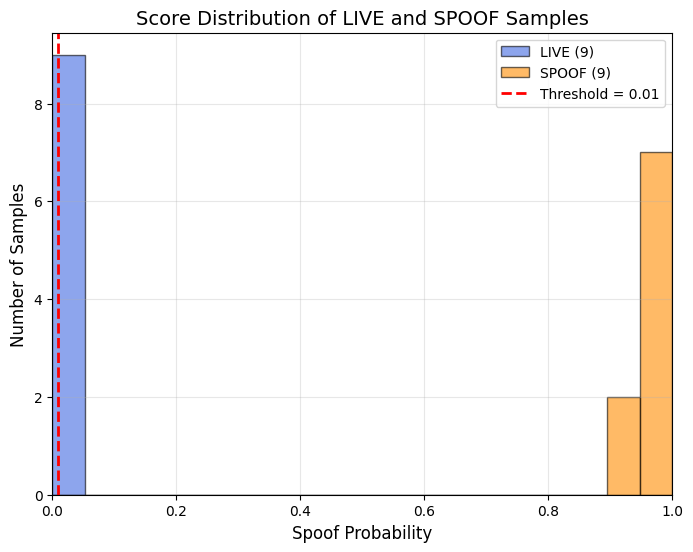

In [48]:
import matplotlib.pyplot as plt
import numpy as np
import os

live_scores = scores[labels == 0]
spoof_scores = scores[labels == 1]

# Choose threshold from validation results
best_idx = np.argmin(np.abs(results[:,1] - results[:,2]))
best_threshold = results[best_idx,0]

plt.figure(figsize=(8,6))

bins = np.linspace(0, 1, 20)

plt.hist(
    live_scores,
    bins=bins,
    alpha=0.6,
    color="royalblue",
    edgecolor="black",
    label=f"LIVE ({len(live_scores)})"
)

plt.hist(
    spoof_scores,
    bins=bins,
    alpha=0.6,
    color="darkorange",
    edgecolor="black",
    label=f"SPOOF ({len(spoof_scores)})"
)

plt.axvline(
    best_threshold,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Threshold = {best_threshold:.2f}"
)

plt.xlim(0,1)

plt.xlabel("Spoof Probability", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
plt.title("Score Distribution of LIVE and SPOOF Samples", fontsize=14)

plt.grid(alpha=0.3)
plt.legend()

save_path="/content/fingerprint-pad/outputs/score_distribution.png"

plt.savefig(save_path,dpi=300,bbox_inches="tight")
plt.show()

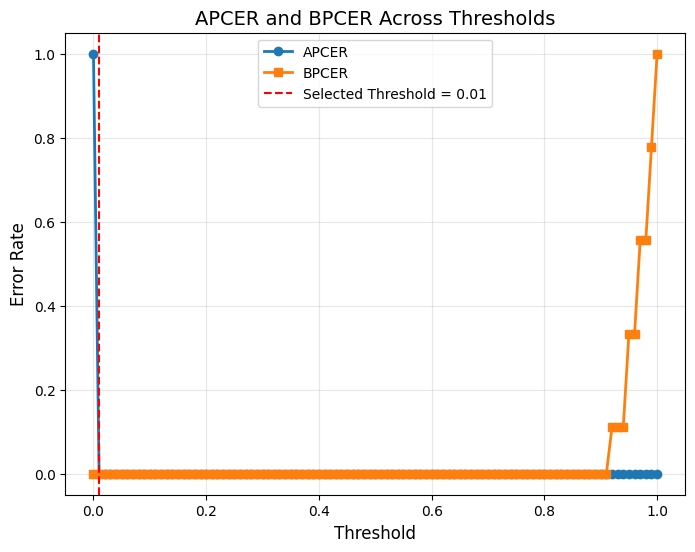

In [49]:
plt.figure(figsize=(8,6))

plt.plot(
    results[:,0],
    results[:,1],
    marker="o",
    linewidth=2,
    label="APCER"
)

plt.plot(
    results[:,0],
    results[:,2],
    marker="s",
    linewidth=2,
    label="BPCER"
)

plt.axvline(
    best_threshold,
    color="red",
    linestyle="--",
    label=f"Selected Threshold = {best_threshold:.2f}"
)

plt.xlabel("Threshold", fontsize=12)
plt.ylabel("Error Rate", fontsize=12)
plt.title("APCER and BPCER Across Thresholds", fontsize=14)

plt.grid(True, alpha=0.3)
plt.legend()

save_path="/content/fingerprint-pad/outputs/apcer_bpcer_curve.png"

plt.savefig(save_path,dpi=300,bbox_inches="tight")
plt.show()

#The validation dataset contains only 18 samples (9 LIVE and 9 SPOOF). Therefore, the threshold calibration is coarse, and metrics such as APCER, BPCER, and EER may change in larger real-world datasets. A larger validation dataset would provide more stable threshold estimation.#


In [59]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model
model = models.mobilenet_v3_small(weights=None)

in_features = model.classifier[3].in_features
model.classifier[3] = nn.Linear(in_features, 2)

model.load_state_dict(
    torch.load("/content/fingerprint-pad/models/liveness_model.pth", map_location=device)
)

model.to(device)
model.eval()

# Transform
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

image_path = "/content/fingerprint-pad/dataset_split/test/live/531__M_Left_ring_finger.BMP"

image = Image.open(image_path).convert("RGB")

image = transform(image).unsqueeze(0).to(device)

with torch.no_grad():

    output = model(image)

    prob = torch.softmax(output, dim=1)

    confidence, prediction = torch.max(prob,1)

classes = ["LIVE","SPOOF"]

print("Prediction :", classes[prediction.item()])
print("Confidence :", f"{confidence.item()*100:.2f}%")

Prediction : LIVE
Confidence : 100.00%


In [61]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model
model = models.mobilenet_v3_small(weights=None)

in_features = model.classifier[3].in_features
model.classifier[3] = nn.Linear(in_features, 2)

model.load_state_dict(
    torch.load("/content/fingerprint-pad/models/liveness_model.pth", map_location=device)
)

model.to(device)
model.eval()

# Transform
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

image_path="/content/fingerprint-pad/dataset_split/test/spoof/398__M_Right_ring_finger.BMP"

image = Image.open(image_path).convert("RGB")

image = transform(image).unsqueeze(0).to(device)

with torch.no_grad():

    output = model(image)

    prob = torch.softmax(output, dim=1)

    confidence, prediction = torch.max(prob,1)

classes = ["LIVE","SPOOF"]

print("Prediction :", classes[prediction.item()])
print("Confidence :", f"{confidence.item()*100:.2f}%")

Prediction : SPOOF
Confidence : 93.26%


#**Test Set Predictions: The trained model was evaluated on all test images. For each image, the actual class, predicted class, and confidence score are displayed to demonstrate the model's performance on unseen data.**


In [62]:
import os
import torch
from PIL import Image

classes = ["LIVE", "SPOOF"]

folders = {
    "LIVE": "/content/fingerprint-pad/dataset_split/test/live",
    "SPOOF": "/content/fingerprint-pad/dataset_split/test/spoof"
}

print("="*80)
print("TEST SET PREDICTIONS")
print("="*80)

correct = 0
total = 0

for actual_class, folder in folders.items():

    print(f"\n{actual_class} Images")
    print("-"*80)

    for filename in sorted(os.listdir(folder)):

        image_path = os.path.join(folder, filename)

        image = Image.open(image_path).convert("RGB")
        image = transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(image)
            probs = torch.softmax(output, dim=1)

            confidence, prediction = torch.max(probs, 1)

        predicted_class = classes[prediction.item()]
        confidence_score = confidence.item() * 100

        if predicted_class == actual_class:
            status = "✓"
            correct += 1
        else:
            status = "✗"

        total += 1

        print(f"{status} {filename}")
        print(f"   Actual      : {actual_class}")
        print(f"   Prediction  : {predicted_class}")
        print(f"   Confidence  : {confidence_score:.2f}%")
        print()

print("="*80)
print(f"Overall Test Accuracy: {correct}/{total} = {(correct/total)*100:.2f}%")
print("="*80)

TEST SET PREDICTIONS

LIVE Images
--------------------------------------------------------------------------------
✓ 290__M_Right_index_finger.BMP
   Actual      : LIVE
   Prediction  : LIVE
   Confidence  : 100.00%

✓ 342__M_Left_middle_finger.BMP
   Actual      : LIVE
   Prediction  : LIVE
   Confidence  : 100.00%

✓ 373__M_Right_ring_finger.BMP
   Actual      : LIVE
   Prediction  : LIVE
   Confidence  : 100.00%

✓ 40__F_Left_thumb_finger.BMP
   Actual      : LIVE
   Prediction  : LIVE
   Confidence  : 100.00%

✓ 507__M_Left_index_finger.BMP
   Actual      : LIVE
   Prediction  : LIVE
   Confidence  : 100.00%

✓ 50__M_Left_little_finger.BMP
   Actual      : LIVE
   Prediction  : LIVE
   Confidence  : 100.00%

✓ 526__F_Left_ring_finger.BMP
   Actual      : LIVE
   Prediction  : LIVE
   Confidence  : 100.00%

✓ 531__M_Left_ring_finger.BMP
   Actual      : LIVE
   Prediction  : LIVE
   Confidence  : 100.00%

✓ 555__M_Left_index_finger.BMP
   Actual      : LIVE
   Prediction  : LIVE
   

In [63]:
!zip -r Fingerprint-Liveness-Detection.zip Fingerprint-Liveness-Detection

  adding: Fingerprint-Liveness-Detection/ (stored 0%)
  adding: Fingerprint-Liveness-Detection/models/ (stored 0%)
  adding: Fingerprint-Liveness-Detection/models/liveness_model.pth (deflated 8%)
  adding: Fingerprint-Liveness-Detection/dataset_split/ (stored 0%)
  adding: Fingerprint-Liveness-Detection/dataset_split/test/ (stored 0%)
  adding: Fingerprint-Liveness-Detection/dataset_split/test/live/ (stored 0%)
  adding: Fingerprint-Liveness-Detection/dataset_split/test/live/531__M_Left_ring_finger.BMP (deflated 77%)
  adding: Fingerprint-Liveness-Detection/dataset_split/test/live/526__F_Left_ring_finger.BMP (deflated 76%)
  adding: Fingerprint-Liveness-Detection/dataset_split/test/live/342__M_Left_middle_finger.BMP (deflated 73%)
  adding: Fingerprint-Liveness-Detection/dataset_split/test/live/555__M_Left_index_finger.BMP (deflated 76%)
  adding: Fingerprint-Liveness-Detection/dataset_split/test/live/40__F_Left_thumb_finger.BMP (deflated 75%)
  adding: Fingerprint-Liveness-Detection/d